# Sim-Exp 一站式对标 `src.compare` 使用示例

演示 `compare_all` 的典型用法：

- 自动按温度 + 倍率模糊匹配仿真标签与实验 CSV；
- 一次性出 retention / efficiency / swelling 三张对比图；
- 用 `filter_conditions` 只看指定工况；
- 用 `sim_bias` / `exp_bias` 做基线修正（**注意会留 trace，慎用**）。

本 notebook 会跑 **2 个最小 PyBaMM aging 仿真**（25°C / 45°C，各 2 圈，启用 SEI），
并在临时目录里造对应的实验 CSV。预计耗时 1–3 分钟。

In [1]:
# --- BatteryProject 路径自动定位 (无论从 root 还是 examples/ 启动 notebook 都能工作) ---
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
for _cand in (_HERE, *_HERE.parents):
    if (_cand / "src" / "easy_imports.py").exists() and (_cand / "pyproject.toml").exists():
        _ROOT = _cand
        break
else:
    raise RuntimeError(f"Cannot locate BatteryProject root from {_HERE}")
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("BatteryProject root:", _ROOT)

BatteryProject root: D:\Users\hez\Desktop\hithium\BatteryProject


In [2]:
from src.easy_imports import *
from src.compare import compare_all, compare_retention, compare_efficiency
from src.exp_loader import load_cycling_folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
import tempfile, shutil
from pathlib import Path

## 1. 跑两个最小 aging 仿真

- 选项：`SEI = ec reaction limited`，加速因子 `t_factor=50`（1 sim cycle ≈ 50 real cycles）；
- 工况：25°C 0.5C / 45°C 0.5C，各 2 sim cycles；
- 求解器：`IDAKLUSolver`，`rtol=atol=1e-6`。

In [3]:
def run_one(temperature_k, n_cycles=2, t_factor=50):
    model = pybamm.lithium_ion.DFN({"SEI": "ec reaction limited"})
    param = pybamm.ParameterValues("OKane2022")
    param.update(get_hithium_params(t_factor=t_factor, temperature=temperature_k),
                 check_already_exists=False)
    param.update({
        "Initial hysteresis state in negative electrode": 0.0,
        "Initial hysteresis state in positive electrode": 0.0,
    }, check_already_exists=False)
    param.update({"Ambient temperature [K]": temperature_k}, check_already_exists=False)

    experiment = pybamm.Experiment([
        ("Discharge at 0.5C until 2.5 V",
         "Rest for 5 minutes",
         "Charge at 0.5C until 3.65 V",
         "Hold at 3.65 V until 0.05C",
         "Rest for 5 minutes")
    ] * n_cycles)

    solver = pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-6)
    var_pts = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 10, "r_p": 10}
    sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment,
                             solver=solver, var_pts=var_pts)
    return sim.solve(calc_esoh=False), param

sol_25, param_25 = run_one(298.15)
sol_45, param_45 = run_one(318.15)

sol_list   = [sol_25, sol_45]
sim_labels = ["25°C 0.5P", "45°C 0.5P"]
print("两次仿真完成；cycles =", [len(s.cycles) for s in sol_list])

两次仿真完成；cycles = [2, 2]


## 2. 造对应的实验 CSV

实际项目中这一步对应测试设备导出的 csv（在 `data/` 下）。
为了让 notebook 自包含，下面在临时目录里造两份**故意带偏差**的实验曲线，
好让对比图看出 sim 与 exp 的差距。

In [4]:
tmp = Path(tempfile.mkdtemp(prefix="compare_demo_"))
print("实验 CSV 临时目录:", tmp)

rng = np.random.default_rng(0)
cycle_real = np.arange(0, 300, 10)

# 故意造的 "实验" 曲线：与仿真有 ~1% 偏差
for T_label, decay_k in [("25", 1.2e-4), ("45", 5e-4)]:
    retention = 1.0 - decay_k * cycle_real + rng.normal(0, 0.002, cycle_real.size)
    discharge_cap = retention * 1175
    charge_cap = discharge_cap / 0.995
    df = pd.DataFrame({
        "循环圈数": cycle_real,
        "放电容量(Ah)": discharge_cap,
        "充电容量(Ah)": charge_cap,
        "容量保持率": retention * 100,  # 百分制
        "能量效率":   retention * 0.997,
    })
    df.to_csv(tmp / f"{T_label}℃-0.5P.csv", index=False, encoding="utf-8-sig")

print("已写入:", [p.name for p in tmp.glob("*.csv")])

实验 CSV 临时目录: C:\Users\hez\AppData\Local\Temp\compare_demo_mbb9u4bo
已写入: ['25℃-0.5P.csv', '45℃-0.5P.csv']


## 3. 一站式对标

`compare_all` 内部会：
1. 加载 `exp_folder` 下所有 CSV → `list[dict]`；
2. 调用 `_auto_match(sim_labels, exp_list)` 按温度/倍率模糊匹配；
3. 对每个匹配对计算 retention/efficiency/swelling 并绘图；
4. 打印未匹配上的 sim/exp 标签提醒。

默认 metrics 是 `["retention", "efficiency", "swelling"]`，可只传子集。


🔗 自动匹配结果 (2 对):
   Sim[25°C 0.5P]  ↔  Exp[25°C 0.5P]
   Sim[45°C 0.5P]  ↔  Exp[45°C 0.5P]


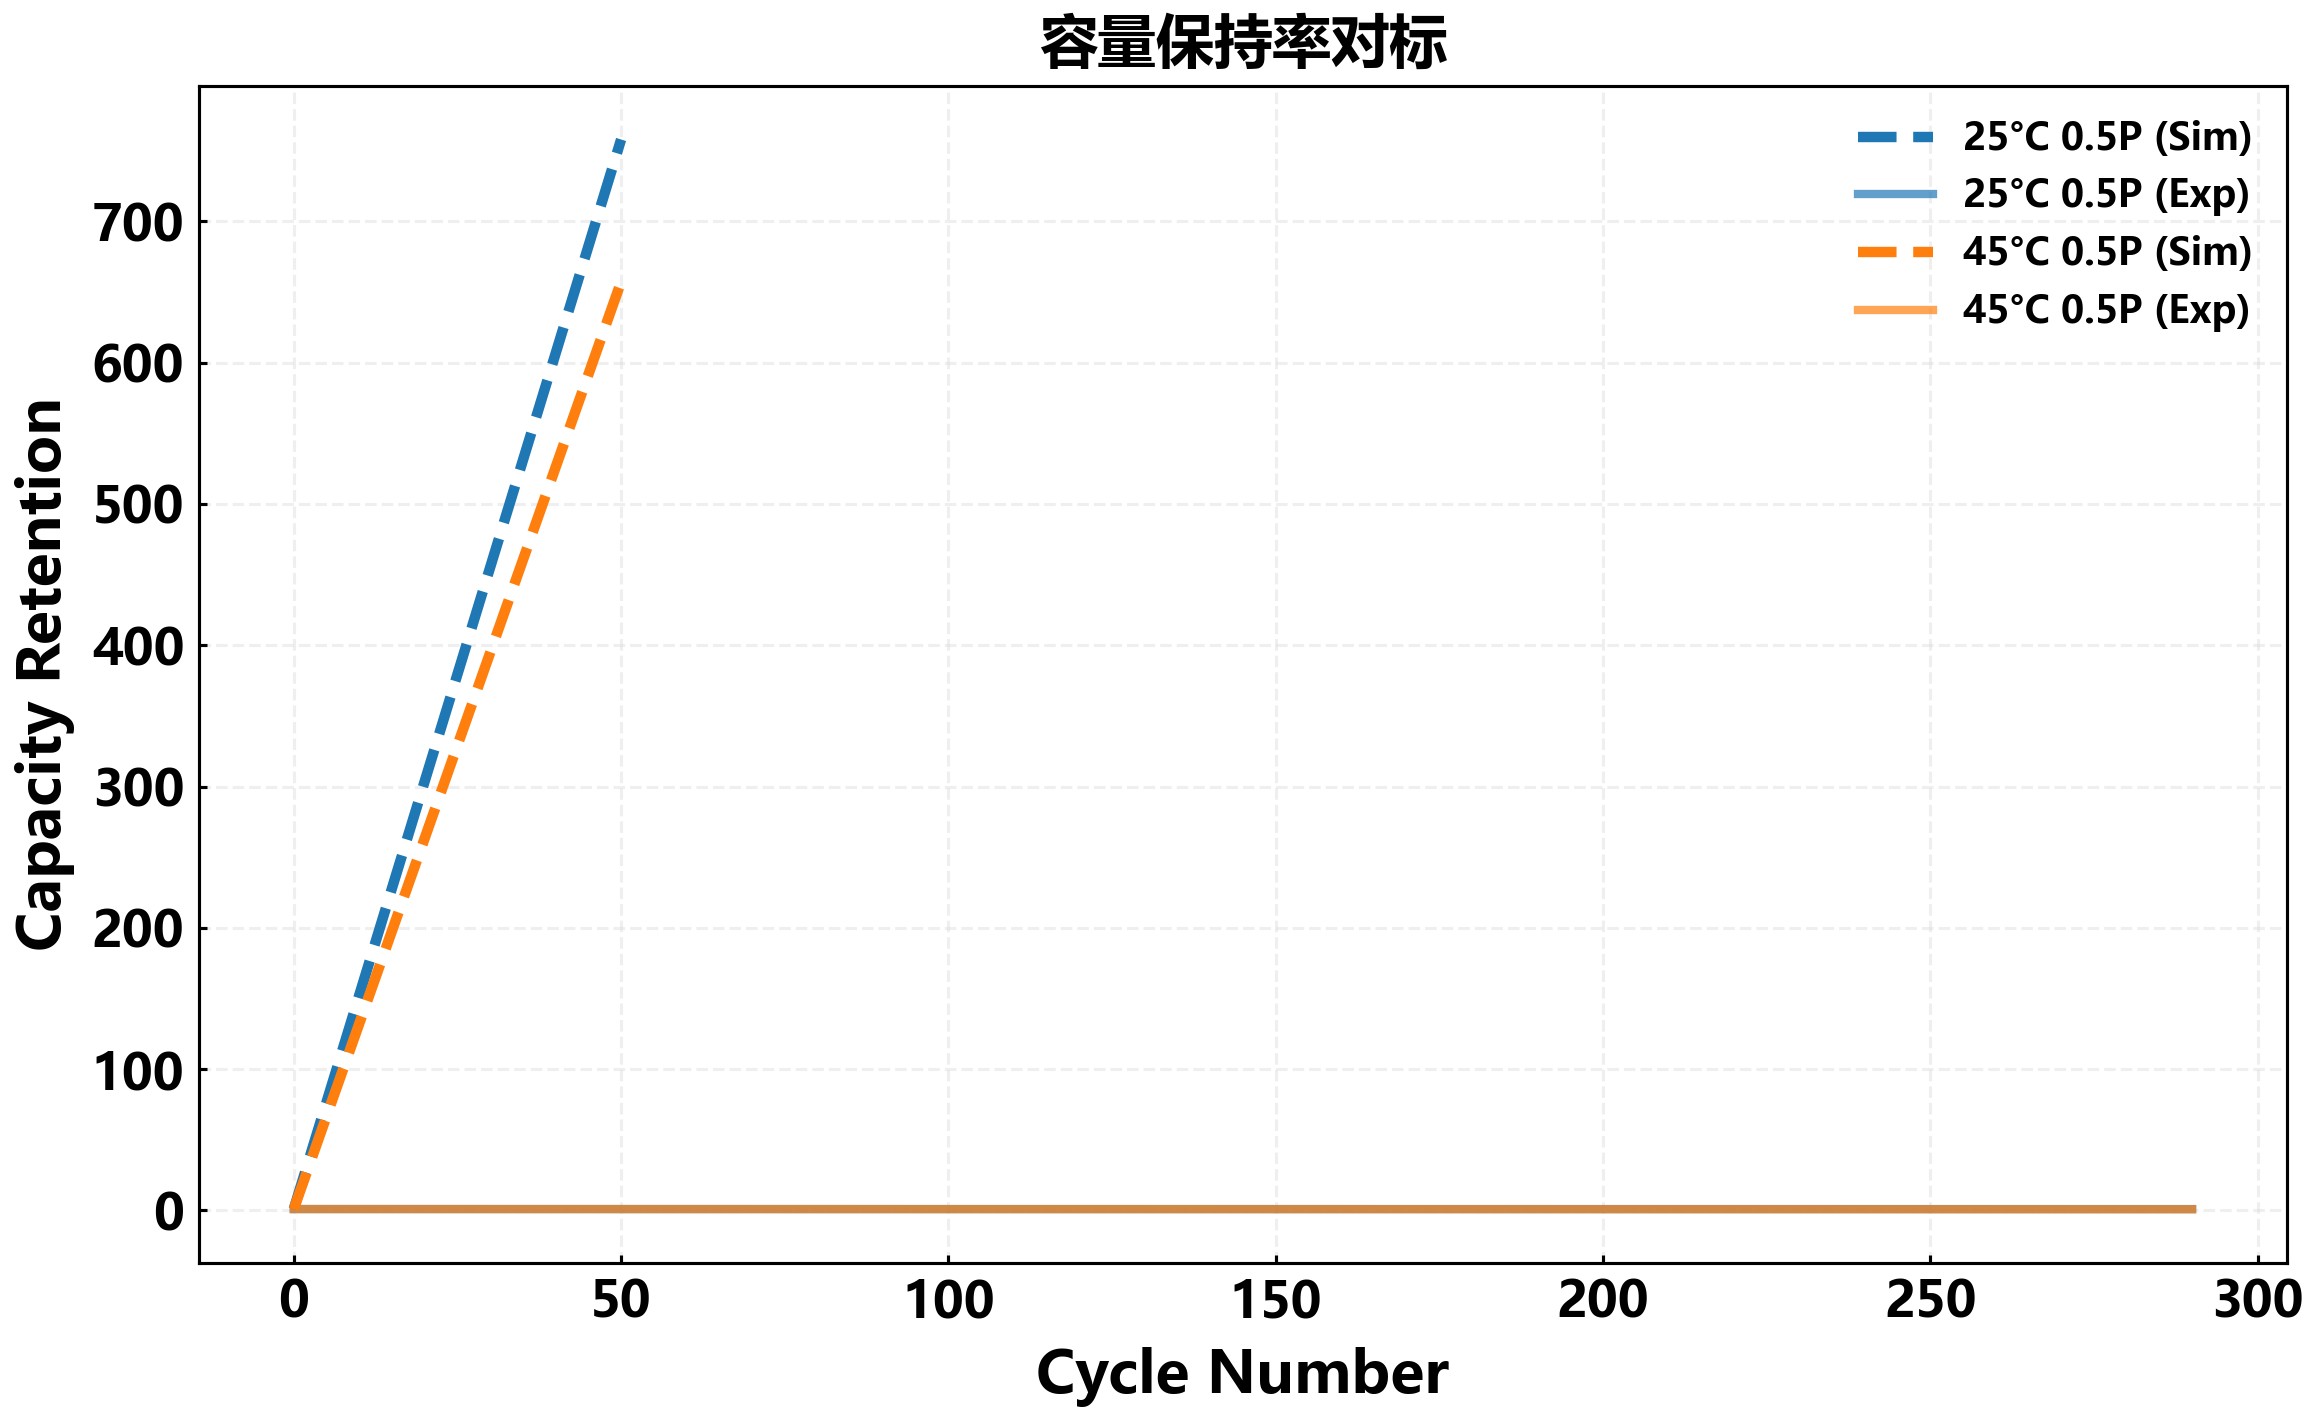

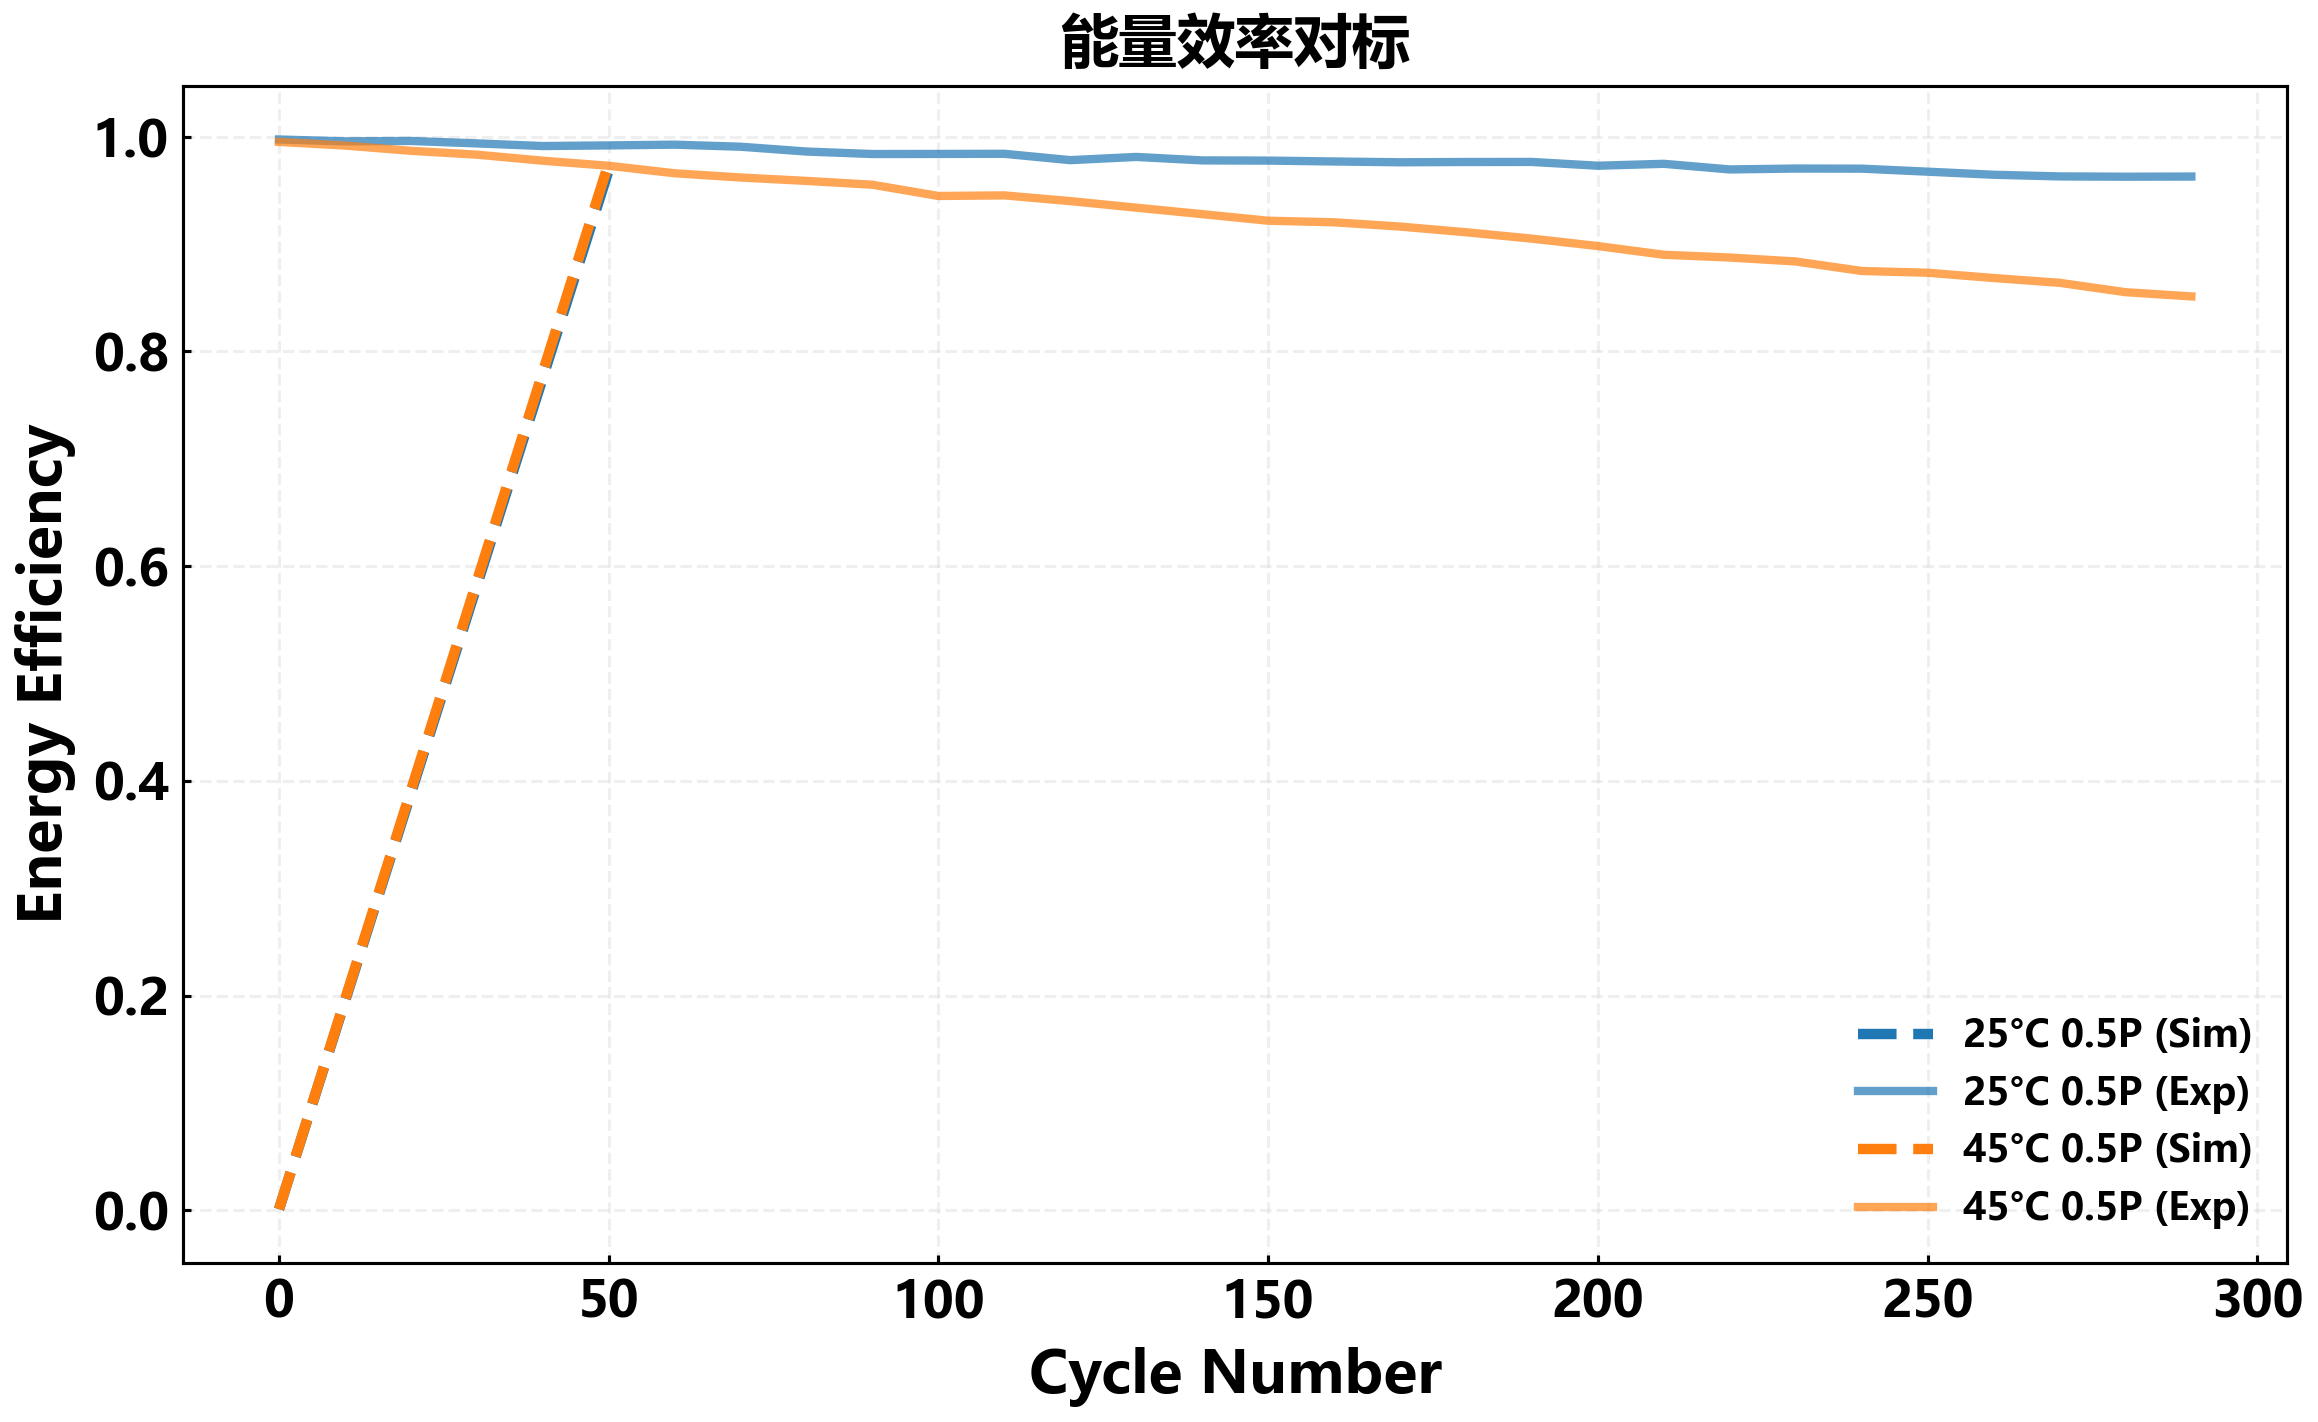

In [5]:
axes = compare_all(
    sol_list=sol_list,
    sim_labels=sim_labels,
    exp_folder=tmp,
    params=param_25,           # 膨胀力需要 params；两条曲线共用 param_25 简化
    acceleration_factor=50,    # 1 sim cycle = 50 real cycles
    metrics=["retention", "efficiency"],   # 先不画膨胀，节省空间
)
plt.show()

## 4. 按工况筛选 `filter_conditions`

传字符串或列表：含 `°C/℃` 的项视为温度筛选，其余视为倍率筛选；
同类 OR、异类 AND（详见 `_match_condition_filter` 的 docstring）。


🔗 自动匹配结果 (1 对):
   Sim[25°C 0.5P]  ↔  Exp[25°C 0.5P]
   ⚠️ 未匹配仿真: ['45°C 0.5P']
   ⚠️ 未匹配实验: ['45°C 0.5P']
   🔍 筛选条件: 25°C


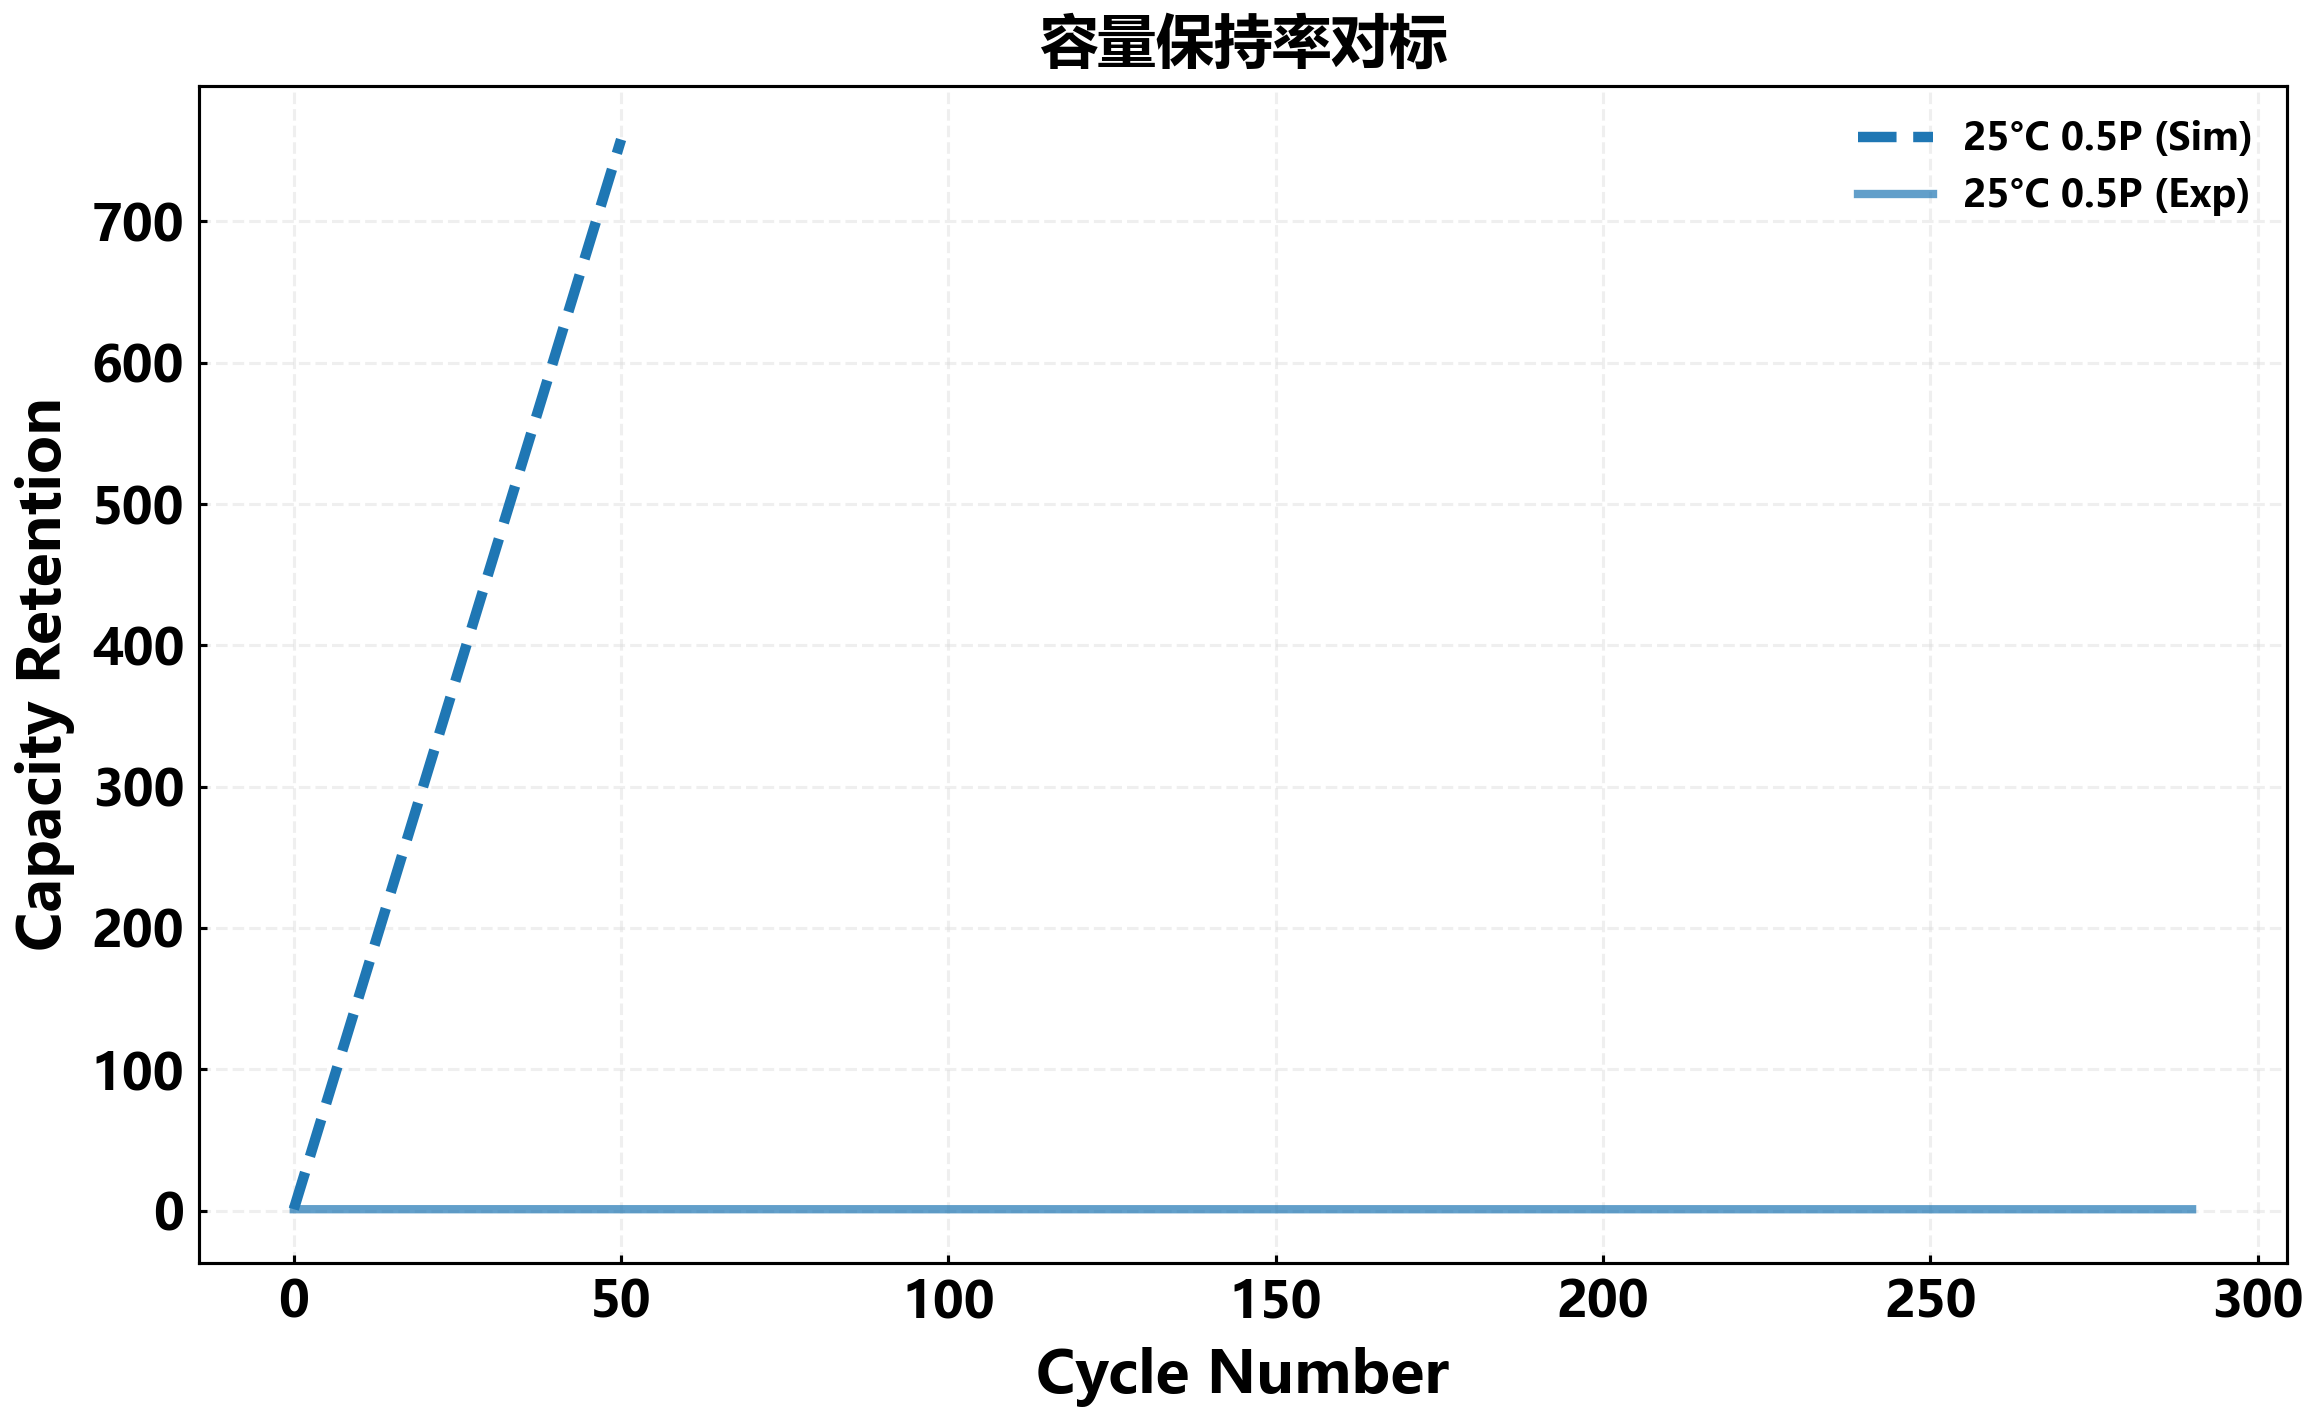

In [6]:
# 只看 25°C 工况
axes_25 = compare_all(
    sol_list=sol_list, sim_labels=sim_labels,
    exp_folder=tmp, params=param_25,
    acceleration_factor=50,
    metrics=["retention"],
    filter_conditions="25°C",
)
plt.show()

## 5. `sim_bias` / `exp_bias` — 基线偏移（**慎用**）

在 retention 曲线整体平移以做基线对齐。
- 标量 → 对所有 metric 同步偏移；
- dict → 分 metric 指定，如 `{"retention": 0.01, "swelling": 50}`。

图例会显式标 `(bias=+0.01)`，但仍**容易被误用为「事后对齐数据」**——
团队约定：只用于硬件偏置（如力传感器零点漂移），不用于隐瞒模型误差。


🔗 自动匹配结果 (2 对):
   Sim[25°C 0.5P]  ↔  Exp[25°C 0.5P]
   Sim[45°C 0.5P]  ↔  Exp[45°C 0.5P]


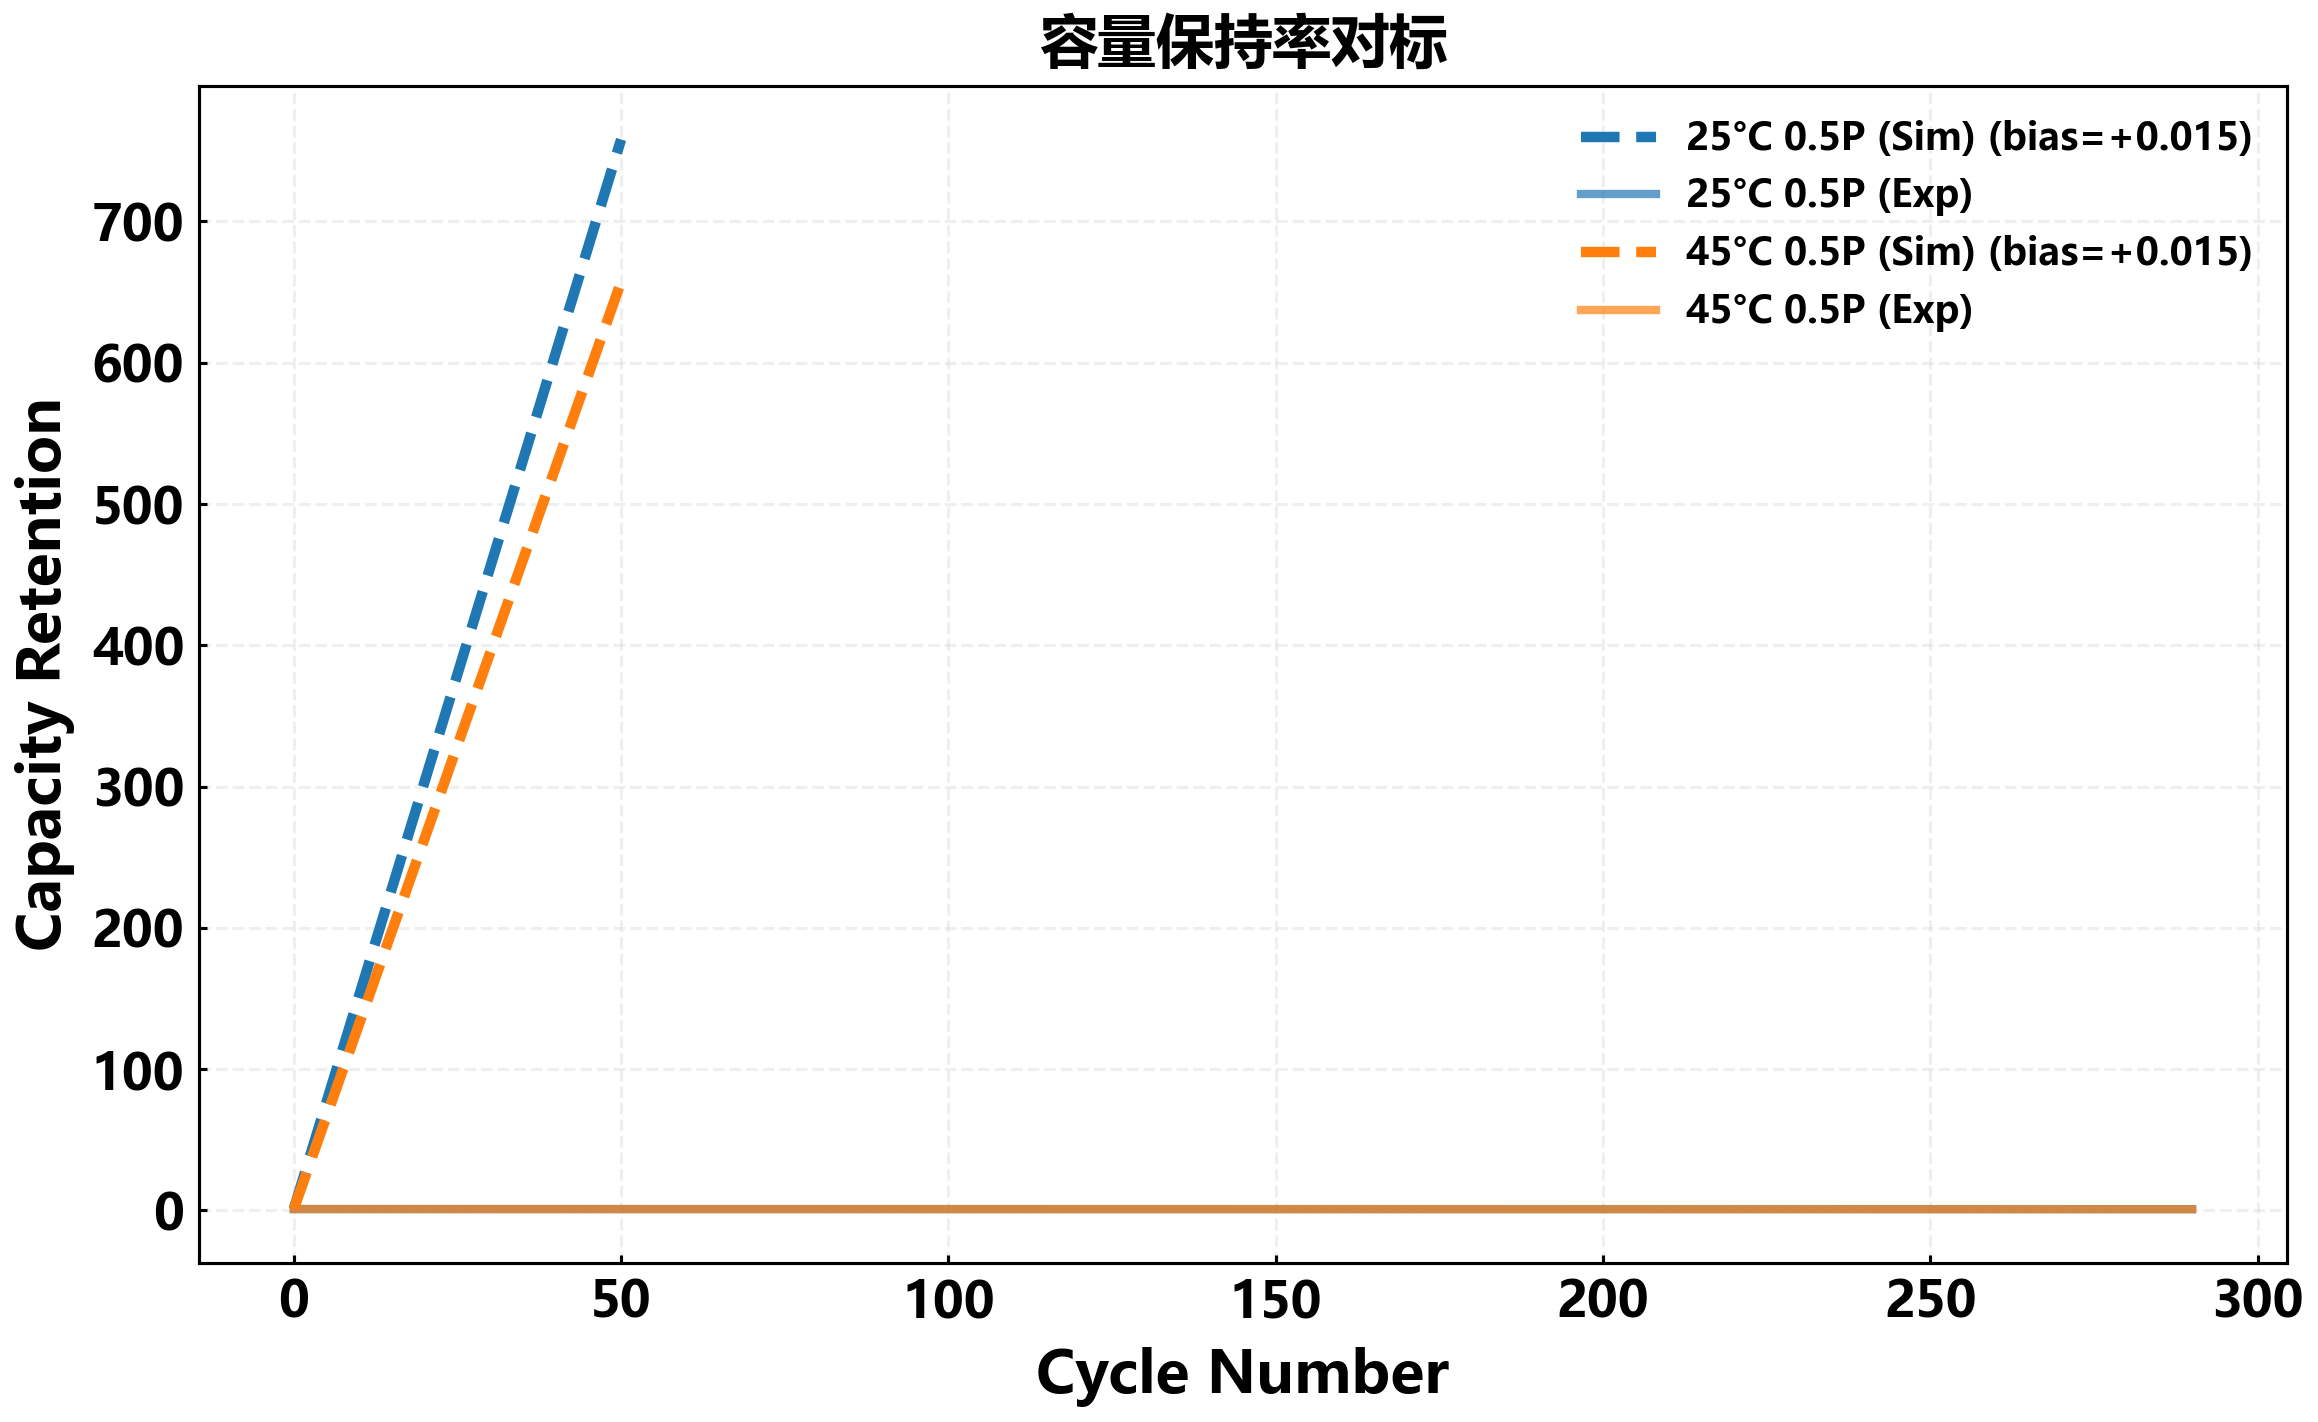

In [7]:
axes_bias = compare_all(
    sol_list=sol_list, sim_labels=sim_labels,
    exp_folder=tmp, params=param_25,
    acceleration_factor=50,
    metrics=["retention"],
    sim_bias={"retention": 0.015},   # 仿真曲线整体上抬 1.5%
)
plt.show()

## 6. 单独使用低阶函数 `compare_retention` / `compare_efficiency`

当你需要把多个 metric 拼到自定义的 figure layout（例如 2x2 subplot）时，
直接用低阶函数，自带 `ax=` 参数。

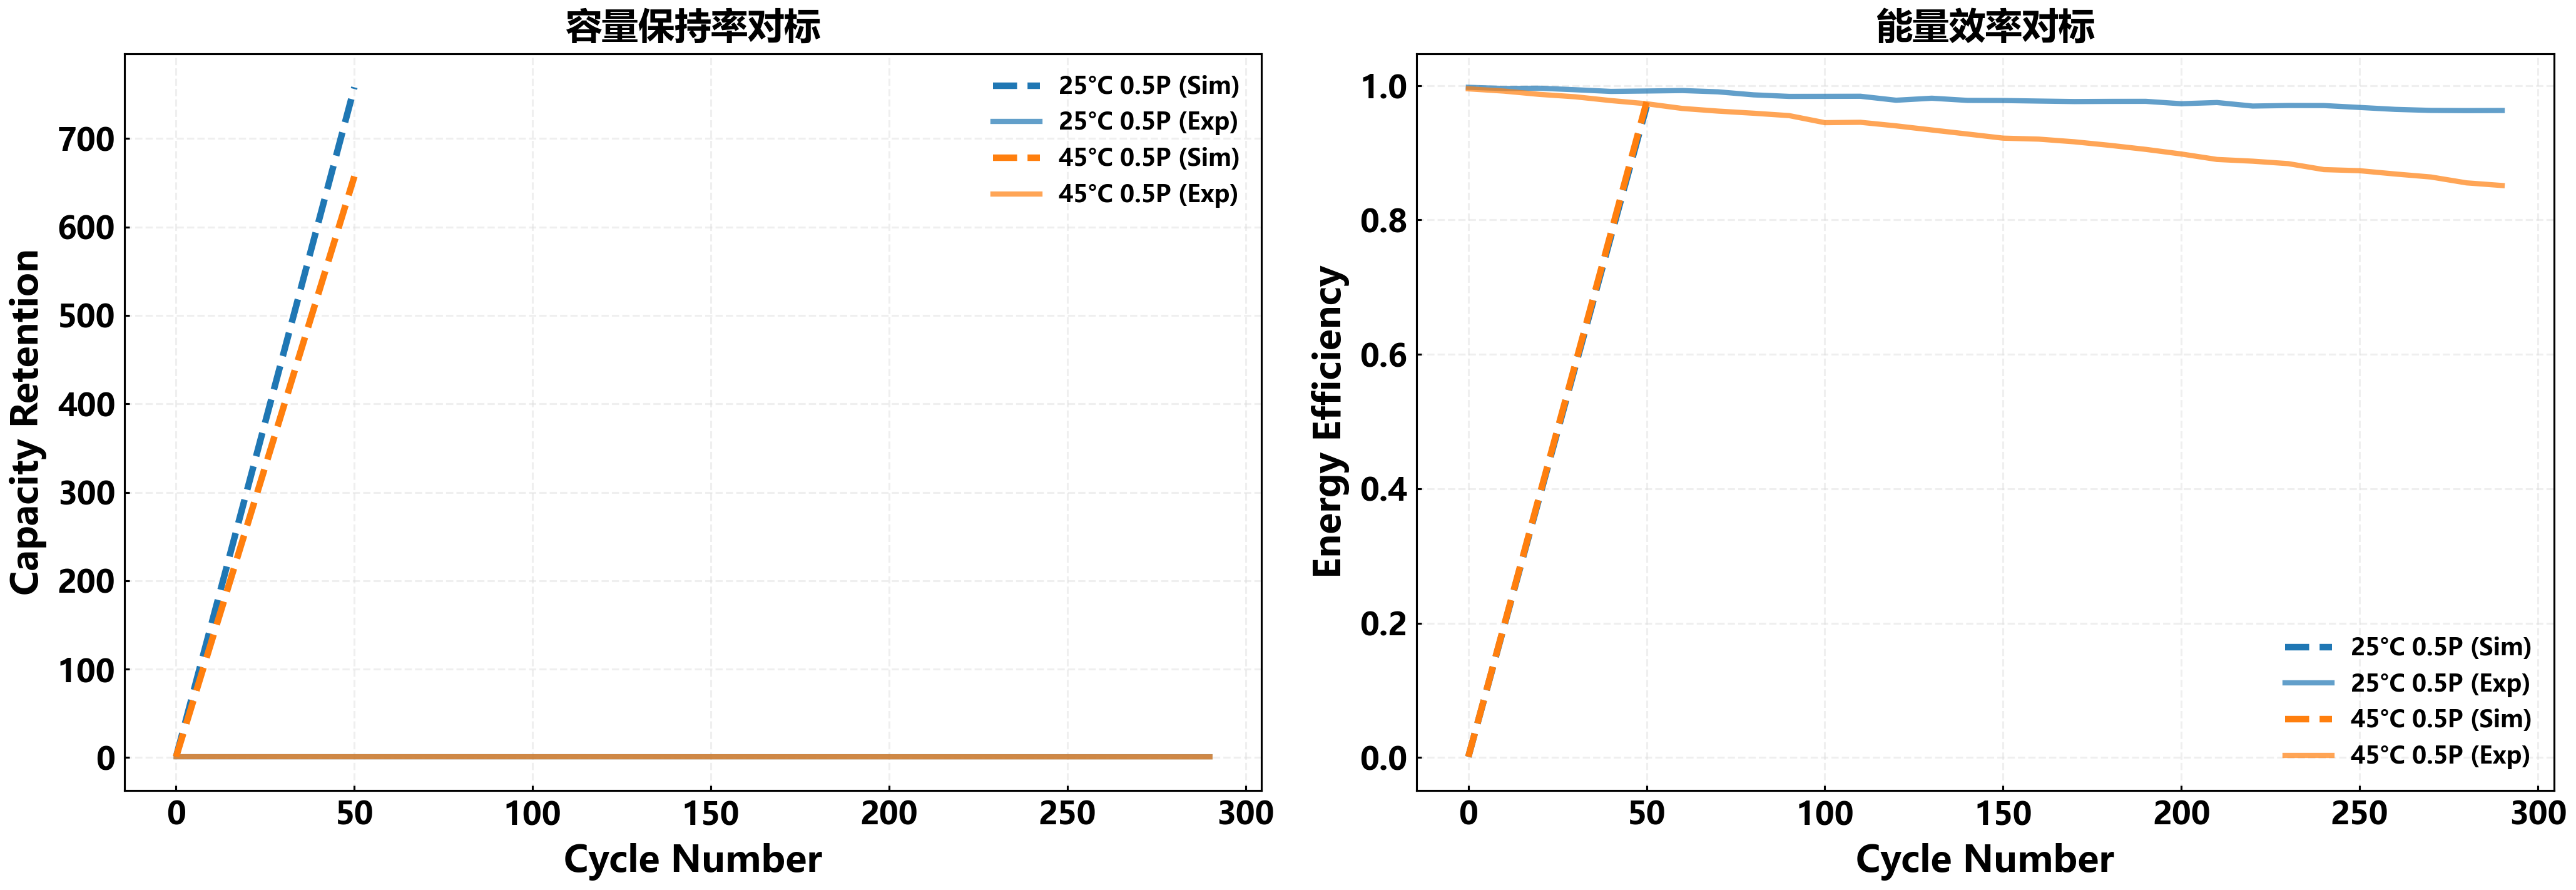

In [8]:
# 自己造 figure，把 retention 与 efficiency 并排
exp_data_list = load_cycling_folder(tmp)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))
compare_retention(sol_list, sim_labels, exp_data_list,
                  acceleration_factor=50, ax=ax_left)
compare_efficiency(sol_list, sim_labels, exp_data_list,
                   acceleration_factor=50, ax=ax_right)
plt.tight_layout()
plt.show()

## 收尾：清理临时目录

In [9]:
shutil.rmtree(tmp)
print("已清理:", tmp)

已清理: C:\Users\hez\AppData\Local\Temp\compare_demo_mbb9u4bo


## 参考

- 实验 CSV 列名约定与多通道支持见 [exp_loader_demo.ipynb](exp_loader_demo.ipynb)。
- 单仿真的指标计算入口见 [analysis_demo.ipynb](analysis_demo.ipynb)。
- `BatteryPlotter` 是 `compare_all` 之外的另一条绘图路径，灵活度更高但需手工注入指标——
  见 [plotting_demo.ipynb](plotting_demo.ipynb)。